In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

DATA_DIR   = 'gtsrb'
TRAIN_DIR  = os.path.join(DATA_DIR, 'Train')
TEST_CSV   = os.path.join(DATA_DIR, 'Test.csv')
TEST_DIR   = DATA_DIR

BATCH_SIZE  = 64
NUM_EPOCHS  = 15
LR          = 1e-4
NUM_CLASSES = 43
VAL_SPLIT   = 0.2
SEED        = 42
CKPT_PATH = 'best_resnet50_gtsrb.pth'

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')
torch.manual_seed(SEED)

Using device: cuda


In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Transforms defined.')

Transforms defined.


In [3]:
class NumericImageFolder(torchvision.datasets.ImageFolder):
    """ImageFolder that sorts class folders by integer value, not alphabetically.
    Default alphabetical sort maps folder '10' -> index 2 instead of 10,
    which misaligns with the integer ClassId values in Test.csv."""
    def find_classes(self, directory):
        classes = sorted(os.listdir(directory), key=lambda x: int(x))
        class_to_idx = {cls: int(cls) for cls in classes}
        return classes, class_to_idx


class GTSRBTestDataset(Dataset):
    def __init__(self, csv_path, root_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['Path'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['ClassId'])
        if self.transform:
            image = self.transform(image)
        return image, label


full_train_dataset = NumericImageFolder(TRAIN_DIR, transform=train_transform)

# Verify mapping is correct: '0'->0, '1'->1, ..., '42'->42
assert full_train_dataset.class_to_idx['10'] == 10, "Label mapping is wrong!"
print(f"Label mapping check passed: class '10' -> index {full_train_dataset.class_to_idx['10']}")

n_total = len(full_train_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val
train_dataset, val_dataset = random_split(
    full_train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
# Apply val transform to the val split
val_dataset.dataset = NumericImageFolder(TRAIN_DIR, transform=val_test_transform)

test_dataset = GTSRBTestDataset(TEST_CSV, TEST_DIR, transform=val_test_transform)

# num_workers=0 avoids Windows multiprocessing spawn overhead in Jupyter
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train samples: {n_train} | Val samples: {n_val} | Test samples: {len(test_dataset)}')
print(f'Classes: {NUM_CLASSES}')

imgs, labels = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}, Labels shape: {labels.shape}')

Label mapping check passed: class '10' -> index 10
Train samples: 31368 | Val samples: 7841 | Test samples: 12630
Classes: 43
Batch shape: torch.Size([64, 3, 224, 224]), Labels shape: torch.Size([64])


In [4]:
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Freeze everything except layer4 and fc
for name, param in model.named_parameters():
    if not (name.startswith('layer4') or name.startswith('fc')):
        param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'Output classes: {model.fc.out_features}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\RA-02/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:03<00:00, 25.9MB/s]


Trainable params: 15,052,843 / 23,596,139
Output classes: 43


In [ ]:
criterion = nn.CrossEntropyLoss()

# Flat LR across all unfrozen parameters (layer4 + fc)
optimizer = torch.optim.Adam([
    {'params': model.layer4.parameters()},
    {'params': model.fc.parameters()},
], lr=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
print('Loss, optimizer (flat LR 1e-4), and scheduler ready.')

In [6]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
CKPT_PATH = 'best_resnet50_gtsrb.pth'

for epoch in range(1, NUM_EPOCHS + 1):
    # --- Train ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    train_loss = running_loss / total
    train_acc  = correct / total

    # --- Validate ---
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    val_loss = running_loss / total
    val_acc  = correct / total

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CKPT_PATH)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}'
          + (' *** saved' if val_acc == best_val_acc else ''))

print(f'\nBest val accuracy: {best_val_acc:.4f}')

Epoch 01/15 | Train Loss: 1.2397 Acc: 0.6557 | Val Loss: 0.4631 Acc: 0.8640 *** saved
Epoch 02/15 | Train Loss: 0.3918 Acc: 0.8763 | Val Loss: 0.2754 Acc: 0.9086 *** saved
Epoch 03/15 | Train Loss: 0.2542 Acc: 0.9161 | Val Loss: 0.2032 Acc: 0.9333 *** saved
Epoch 04/15 | Train Loss: 0.1856 Acc: 0.9400 | Val Loss: 0.1415 Acc: 0.9571 *** saved
Epoch 05/15 | Train Loss: 0.1422 Acc: 0.9537 | Val Loss: 0.1293 Acc: 0.9587 *** saved
Epoch 06/15 | Train Loss: 0.1195 Acc: 0.9613 | Val Loss: 0.1165 Acc: 0.9639 *** saved
Epoch 07/15 | Train Loss: 0.1016 Acc: 0.9661 | Val Loss: 0.0923 Acc: 0.9710 *** saved
Epoch 08/15 | Train Loss: 0.0853 Acc: 0.9718 | Val Loss: 0.0863 Acc: 0.9730 *** saved
Epoch 09/15 | Train Loss: 0.0779 Acc: 0.9743 | Val Loss: 0.0797 Acc: 0.9760 *** saved
Epoch 10/15 | Train Loss: 0.0713 Acc: 0.9768 | Val Loss: 0.0787 Acc: 0.9769 *** saved
Epoch 11/15 | Train Loss: 0.0646 Acc: 0.9799 | Val Loss: 0.0736 Acc: 0.9767
Epoch 12/15 | Train Loss: 0.0617 Acc: 0.9808 | Val Loss: 0.0781 

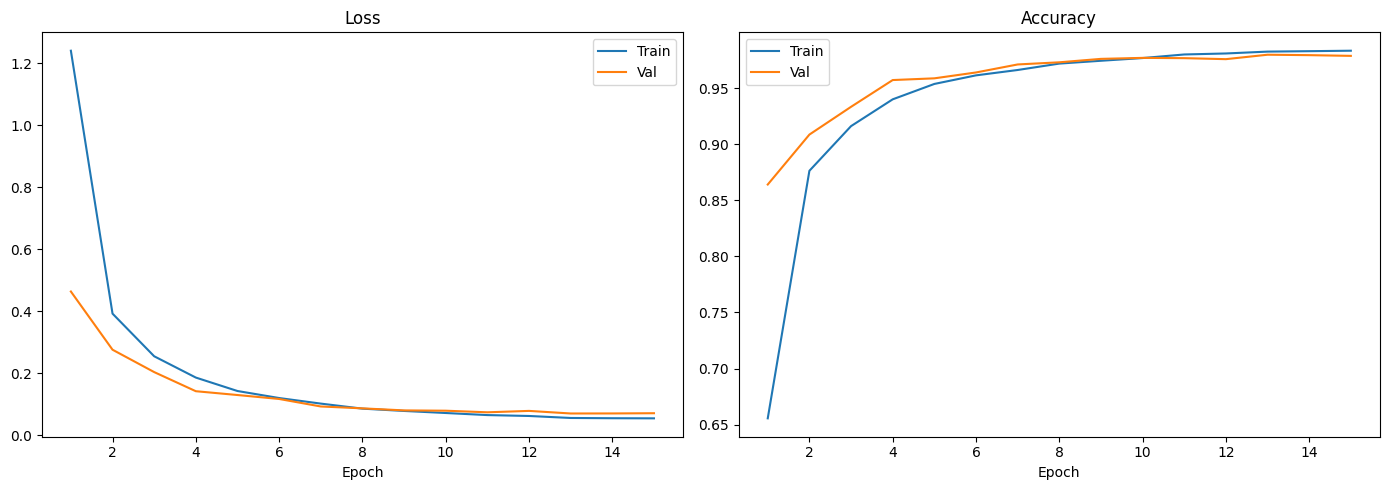

In [7]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import classification_report, accuracy_score

if 'model' not in dir() or next(model.parameters()).device != device:
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model = model.to(device)

CKPT_PATH = 'best_resnet50_gtsrb.pth'
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print()
print(classification_report(all_labels, all_preds, digits=3))

Test Accuracy: 0.9193 (91.93%)

              precision    recall  f1-score   support

           0      1.000     0.517     0.681        60
           1      0.927     0.946     0.936       720
           2      0.826     0.937     0.878       750
           3      0.936     0.780     0.851       450
           4      0.937     0.964     0.950       660
           5      0.922     0.860     0.890       630
           6      0.965     0.907     0.935       150
           7      0.951     0.947     0.949       450
           8      0.899     0.944     0.921       450
           9      0.975     0.988     0.981       480
          10      0.989     0.985     0.987       660
          11      0.891     0.917     0.904       420
          12      1.000     0.959     0.979       690
          13      0.972     0.997     0.984       720
          14      0.989     1.000     0.994       270
          15      0.986     0.990     0.988       210
          16      0.968     0.993     0.980      

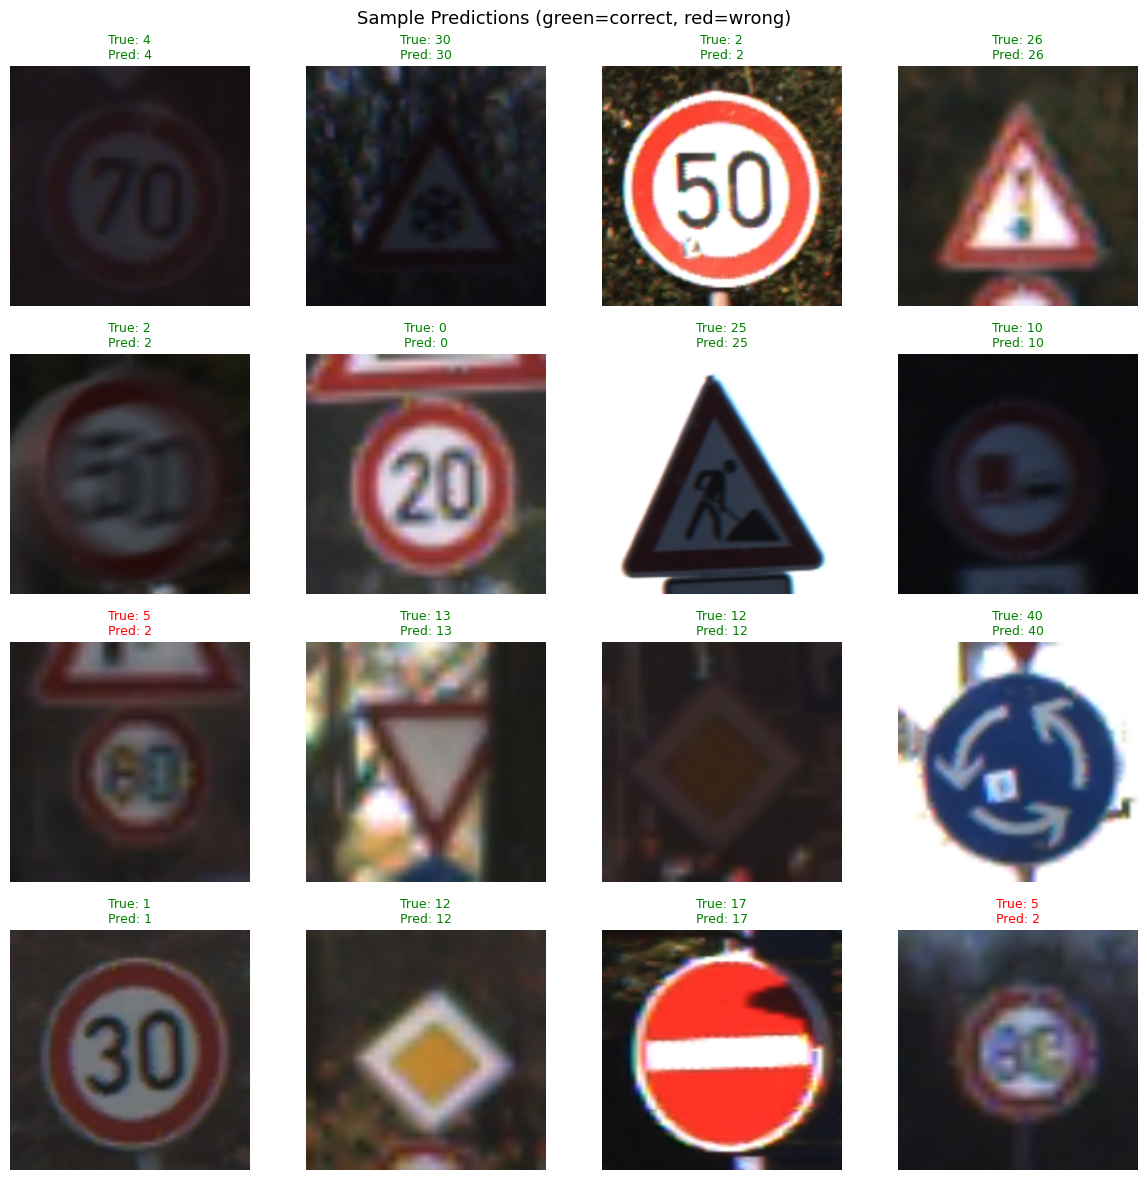

In [9]:
import random

inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)

random.seed(42)
indices = random.sample(range(len(test_dataset)), 16)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

model.eval()
with torch.no_grad():
    for ax, idx in zip(axes.flat, indices):
        img_tensor, true_label = test_dataset[idx]
        pred_label = model(img_tensor.unsqueeze(0).to(device)).argmax(1).item()
        img_show = inv_normalize(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(img_show)
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=9)
        ax.axis('off')

plt.suptitle('Sample Predictions (green=correct, red=wrong)', fontsize=13)
plt.tight_layout()
plt.show()